In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam


In [6]:
# Load Dataset
df = pd.read_csv('monthly_milk_production.csv')
print(df)



        Date  Production
0    1962-01         589
1    1962-02         561
2    1962-03         640
3    1962-04         656
4    1962-05         727
..       ...         ...
163  1975-08         858
164  1975-09         817
165  1975-10         827
166  1975-11         797
167  1975-12         843

[168 rows x 2 columns]


In [7]:
print(df.info())

print("\nChecking Missing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
None

Checking Missing Values:
Date          0
Production    0
dtype: int64


In [8]:
# Convert Date column to datetime
df.columns = ['Month', 'Milk_Production']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print("\nDate column converted and set as index.")



Date column converted and set as index.


In [9]:
print(df)


            Milk_Production
Month                      
1962-01-01              589
1962-02-01              561
1962-03-01              640
1962-04-01              656
1962-05-01              727
...                     ...
1975-08-01              858
1975-09-01              817
1975-10-01              827
1975-11-01              797
1975-12-01              843

[168 rows x 1 columns]


In [12]:
# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

print("Data Normalized Successfully!")
print("normalized values:")
print(scaled_data[:-1])


Data Normalized Successfully!
normalized values:
[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]
 [0.34615385]
 [0.20913462]
 [0.11057692]
 [0.03605769]
 [0.05769231]
 [0.        ]
 [0.06971154]
 [0.11298077]
 [0.03125   ]
 [0.24038462]
 [0.28846154]
 [0.45432692]
 [0.39182692]
 [0.25721154]
 [0.15384615]
 [0.07211538]
 [0.08173077]
 [0.02884615]
 [0.10817308]
 [0.18028846]
 [0.15625   ]
 [0.32451923]
 [0.36538462]
 [0.52163462]
 [0.43990385]
 [0.30048077]
 [0.20673077]
 [0.12259615]
 [0.13942308]
 [0.09855769]
 [0.19471154]
 [0.25240385]
 [0.16586538]
 [0.375     ]
 [0.40625   ]
 [0.55048077]
 [0.48798077]
 [0.35817308]
 [0.24038462]
 [0.14903846]
 [0.16346154]
 [0.11778846]
 [0.19711538]
 [0.29807692]
 [0.19711538]
 [0.43990385]
 [0.48557692]
 [0.62019231]
 [0.58894231]
 [0.4375    ]
 [0.34615385]
 [0.25961538]
 [0.27403846]
 [0.22115385]
 [0.32451923]
 [0.38461538]
 [0.27403846]
 [0.50240385]
 [0.55528846]
 [0.68269231]
 [0.63461538]
 [0.51442308]
 [0.40625   ]

In [13]:
# Create Time Windows

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12

X, y = create_sequences(scaled_data, window_size)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (156, 12, 1)
Shape of y: (156, 1)


In [ ]:

# Train-Test Split

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 124
Testing Samples: 32


In [16]:
# Build Basic RNN Model


rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("RNN Model Built Successfully")

rnn_model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=1)


RNN Model Built Successfully
Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4327
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0708
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0174 
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0143
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0084
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0054
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0045
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0035
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0029
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 
Epoch 13/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025 
Epoch 14/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024 
Epoch 15/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 
Epoch

In [17]:
# Build LSTM Model

lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("LSTM Model Built Successfully")

lstm_model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=1)


LSTM Model Built Successfully
Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2351
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0871 
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0303 
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0315 
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0290 
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0252 
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0263 
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0239 
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0247
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0239
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0233
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0230 
Epoch 13/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0238
Epoch 14/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0206 
Epoch 15/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0218 
Epoch

In [18]:
#  Build GRU Model

gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("GRU Model Built Successfully")

gru_model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=1)


GRU Model Built Successfully
Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0791
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0223 
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0296 
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0214
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0229 
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0214
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0183
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0181
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0167
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0177
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0187 
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0175
Epoch 13/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0154
Epoch 14/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0158
Epoch 15/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0155
Epoch 

In [21]:
# Model Evaluation
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)
    mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

    return rmse, mae, mape, predictions, y_test_actual


In [22]:
rnn_rmse, rnn_mae, rnn_mape, rnn_pred, y_actual = evaluate_model(rnn_model, X_test, y_test)

print("RNN RMSE:", rnn_rmse)
print("RNN MAE:", rnn_mae)
print("RNN MAPE:", rnn_mape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
RNN RMSE: 19.12700932046321
RNN MAE: 16.558473587036122
RNN MAPE: 1.9423270993754578


In [24]:

rnn_rmse, rnn_mae, rnn_mape, rnn_pred, y_actual = evaluate_model(rnn_model, X_test, y_test)
print("\nEvaluating RNN Model")
print("RNN RMSE:", rnn_rmse)
print("RNN MAE:", rnn_mae)
print("RNN MAPE:", rnn_mape)

print("\nEvaluating LSTM Model")
lstm_rmse, lstm_mae, lstm_mape, lstm_pred, _ = evaluate_model(lstm_model, X_test, y_test)

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE:", lstm_mae)
print("LSTM MAPE:", lstm_mape)

print("\nEvaluating GRU Model")
gru_rmse, gru_mae, gru_mape, gru_pred, _ = evaluate_model(gru_model, X_test, y_test)

print("GRU RMSE:", gru_rmse)
print("GRU MAE:", gru_mae)
print("GRU MAPE:", gru_mape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Evaluating RNN Model
RNN RMSE: 19.12700932046321
RNN MAE: 16.558473587036122
RNN MAPE: 1.9423270993754578

Evaluating LSTM Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
LSTM RMSE: 50.482741171274554
LSTM MAE: 41.828500747680664
LSTM MAPE: 5.067343263898458

Evaluating GRU Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
GRU RMSE: 45.86076337341022
GRU MAE: 35.598442077636705
GRU MAPE: 4.0937986182041755


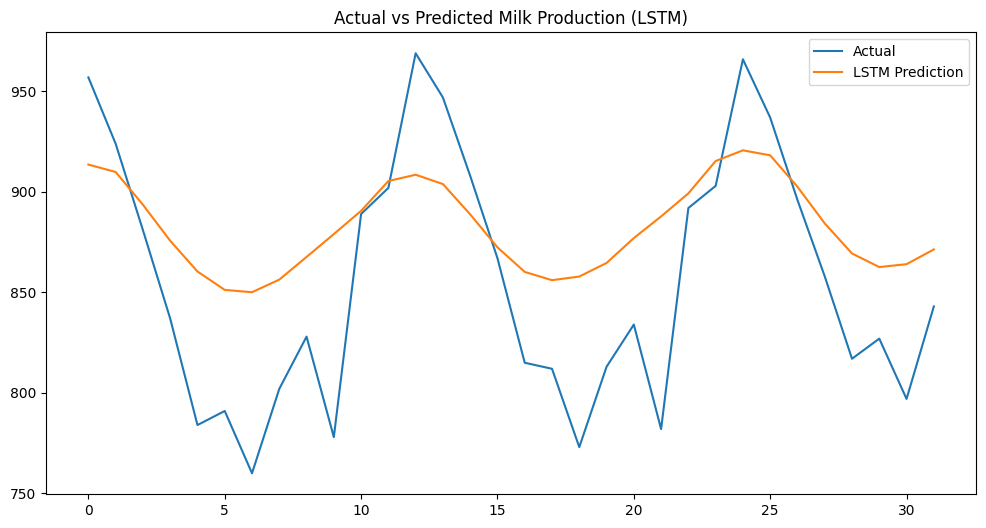

In [25]:
# Plot predictions vs Actiual
plt.figure(figsize=(12,6))
plt.plot(y_actual, label="Actual")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.legend()
plt.title("Actual vs Predicted Milk Production (LSTM)")
plt.show()


In [27]:
# Forecast Future 12 Months


last_sequence = scaled_data[-window_size:]
future_predictions = []

current_sequence = last_sequence.reshape(1, window_size, 1)

for i in range(12):

    next_pred = lstm_model.predict(current_sequence, verbose=0)

    future_predictions.append(next_pred[0,0])

    # Reshape prediction properly to (1,1,1)
    next_pred_reshaped = next_pred.reshape(1,1,1)

    # Remove first time step and append new prediction
    current_sequence = np.concatenate(
        (current_sequence[:,1:,:], next_pred_reshaped),
        axis=1
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print("Next 12 Months Forecast:")
print(future_predictions)


Next 12 Months Forecast:
[[884.157  ]
 [897.9414 ]
 [920.2686 ]
 [927.1674 ]
 [929.6055 ]
 [917.7513 ]
 [903.9966 ]
 [893.6929 ]
 [889.5415 ]
 [894.70105]
 [901.53284]
 [916.65454]]


In [28]:
# Calculate residual errors using LSTM test predictions
residuals = y_actual - lstm_pred
std_error = np.std(residuals)

print("Standard Deviation of Errors:", std_error)


Standard Deviation of Errors: 42.92740497080611


In [31]:
# 95% Confidence Interval
upper_bound = future_predictions + 1.96 * std_error
lower_bound = future_predictions - 1.96 * std_error
print(upper_bound)
print(lower_bound)

[[ 968.29469616]
 [ 982.07911999]
 [1004.40632947]
 [1011.30513318]
 [1013.74324353]
 [1001.88899548]
 [ 988.13429577]
 [ 977.83058484]
 [ 973.67921765]
 [ 978.83876355]
 [ 985.67055066]
 [1000.79225476]]
[[800.01926868]
 [813.80369251]
 [836.13090198]
 [843.02970569]
 [845.46781604]
 [833.613568  ]
 [819.85886829]
 [809.55515735]
 [805.40379016]
 [810.56333606]
 [817.39512317]
 [832.51682727]]


In [32]:
# Create future date index
last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=13,
    freq='M'
)[1:]

print("\nFuture Dates:")
print(future_dates)



Future Dates:
DatetimeIndex(['1976-01-31', '1976-02-29', '1976-03-31', '1976-04-30',
               '1976-05-31', '1976-06-30', '1976-07-31', '1976-08-31',
               '1976-09-30', '1976-10-31', '1976-11-30', '1976-12-31'],
              dtype='datetime64[ns]', freq='ME')


/tmp/ipython-input-874441274.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


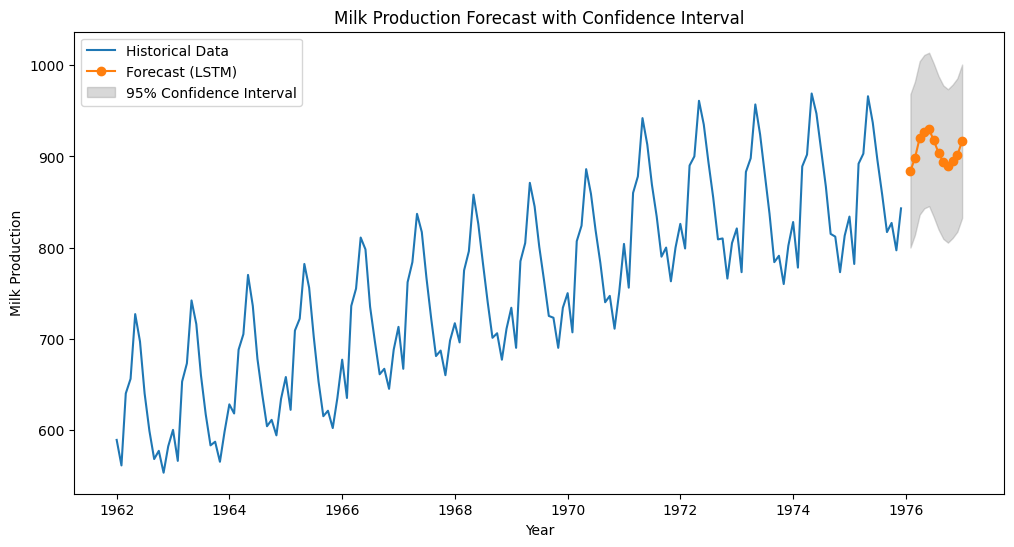

In [34]:
plt.figure(figsize=(12,6))

# Historical data
plt.plot(df.index, df['Milk_Production'], label="Historical Data")

# Forecast
plt.plot(future_dates, future_predictions, label="Forecast (LSTM)", marker='o')

# Confidence Interval
plt.fill_between(
    future_dates,
    lower_bound.flatten(),
    upper_bound.flatten(),
    color='gray',
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("Milk Production Forecast with Confidence Interval")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.legend()
plt.show()


In [ ]:
# Business Insight :

#The LSTM model performed better compared to RNN and GRU in capturing seasonal trends.
#The forecast indicates seasonal fluctuations in milk production

#The dairy company can use these predictions to:
#Plan workforce scheduling
#Optimize storage capacity
#Adjust supply chain distribution
#Prevent overproduction or shortages